In [41]:
import pickle
with open('Data/out-of-sample/optimal_portfolios_0322_minimum_weight.pkl', 'rb') as file:
    data = pickle.load(file)

In [42]:
data

{'Consumer Discretionary': {'w_b_vec': array([0.32718568, 0.00806337, 0.00441375, 0.00712766, 0.00182739,
         0.01201964, 0.0052284 , 0.00342646, 0.00794754, 0.00396822,
         0.00239519, 0.07307296, 0.0044091 , 0.0040399 , 0.03157859,
         0.00368374, 0.0432023 , 0.00149375, 0.01568117, 0.00333172,
         0.0403318 , 0.00149977, 0.00232776, 0.00654253, 0.00359661,
         0.0037585 , 0.00287872, 0.0230012 , 0.00582021, 0.00407169,
         0.00220386, 0.00171979, 0.00305727, 0.00343262, 0.01681913,
         0.00307157, 0.00301894, 0.00148568, 0.00942652, 0.00483095,
         0.00112524, 0.00402874, 0.0010655 , 0.20329236, 0.01072772,
         0.01339346, 0.00636836, 0.00765019, 0.00182348, 0.02261072,
         0.00205659, 0.00302117, 0.00283571, 0.00350744, 0.0095017 ]),
  'w_opt': array([ 3.33740304e-01,  2.59387180e-02, -2.47613878e-13, -2.99770561e-11,
          1.00471803e-02, -1.86341377e-11,  7.20357614e-03,  8.89887786e-03,
          1.91177570e-02,  2.44014901e-

absolute starting carbon emission, carbon reduction, returns, volatility, 

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

periods = ['1221', '0322', '0622', '0922', '1222']   # use yours
nice_label = {'1221':'Dec-2021', '0322':'Mar-2022', '0622':'Jun-2022',
              '0922':'Sep-2022', '1222':'Dec-2022'}

final_rows = []      # “top” table (final values per sector)
# If you also need the returns block, capture it similarly (omitted here for brevity)

for p in periods:
    df = pd.read_excel(f"Data/te-testing-results/benchmark_vs_decarb_final_value_equal_weight_{p}.xlsx")

    # Find the split where the second block (“Benchmark_Return (%)”) starts
    split_row = df.index[df.iloc[:,0].astype(str).str.contains('Benchmark_Return', na=False)]
    split_row = int(split_row[0]) if len(split_row) else len(df)

    top = df.iloc[:split_row].copy()
    top = top.rename(columns={top.columns[0]: "Sector"})
    # keep only the columns we need (adjust names to your sheet)
    top = top[['Sector','Benchmark_Final','Optimised_Final','Difference ($)']]
    top['Period'] = p
    final_rows.append(top)

final_df = pd.concat(final_rows, ignore_index=True)
# Percent difference for heatmap
final_df['Diff_%'] = final_df['Difference ($)'] / final_df['Benchmark_Final']


In [35]:
final_df

,Sector,Benchmark_Final,Optimised_Final,Difference ($),Period,Diff_%
0,Consumer Discretionary,95451.16,92838.60,-2612.56,1221,-0.027371
1,Health Care,108278.23,107533.62,-744.62,1221,-0.006877
2,Utilities,114940.45,111387.24,-3553.21,1221,-0.030913
3,Information Technology,96738.35,96042.41,-695.93,1221,-0.007194
4,Real Estate,105724.43,106590.82,866.39,1221,0.008195
5,Materials,107603.29,104825.25,-2778.04,1221,-0.025817
6,Industrials,106775.58,104626.76,-2148.82,1221,-0.020125
7,Financials,103952.10,102041.76,-1910.34,1221,-0.018377
8,Energy,146500.42,145048.81,-1451.61,1221,-0.009909
9,Communication Services,95364.77,93379.30,-1985.47,1221,-0.020820


What happens if you invest 100k in each sector and then you compare what happens in each sector decarbonised portfolio (fixed weights for the next 3 months) vs the real sector benchmark?

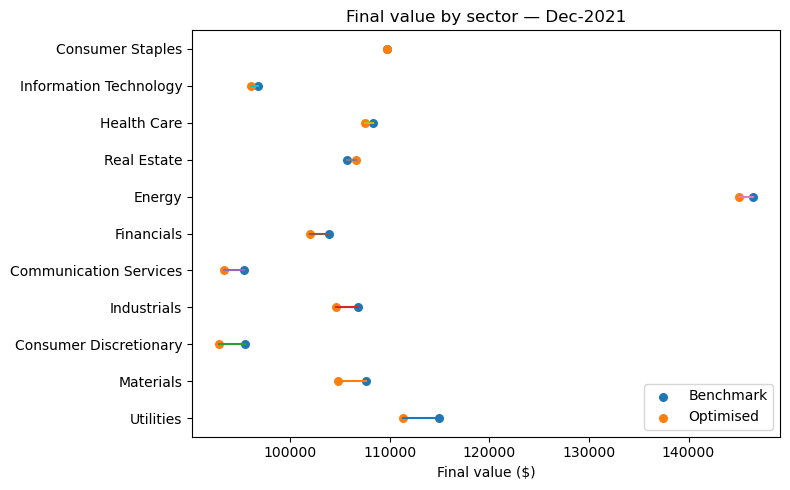

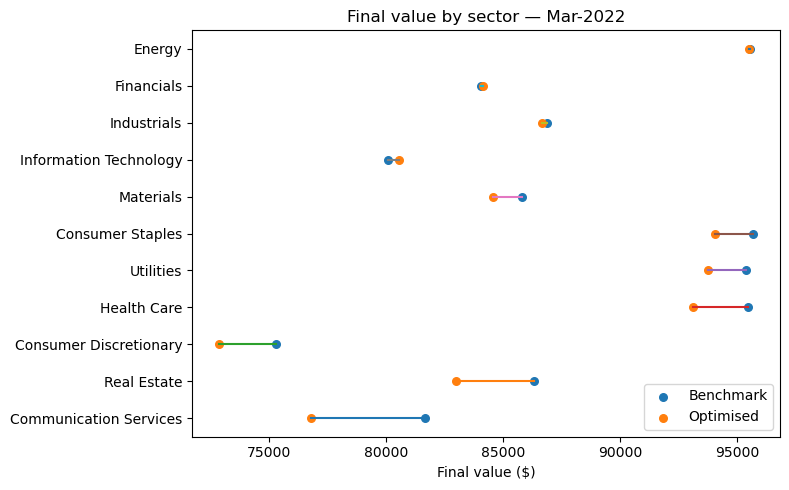

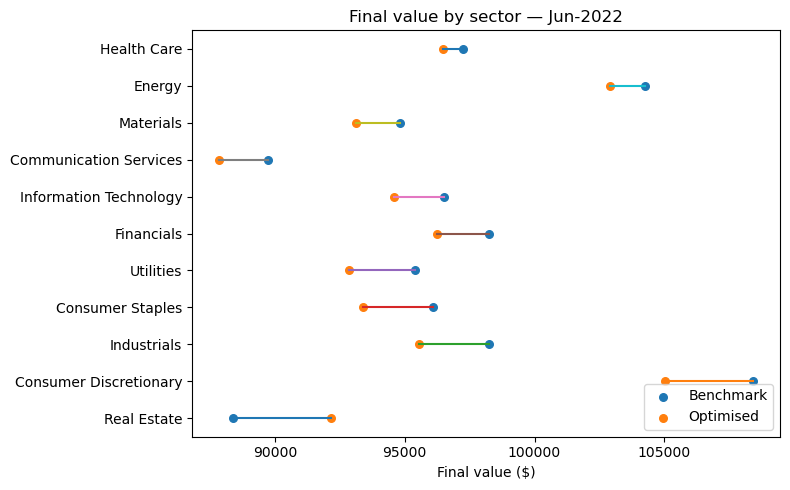

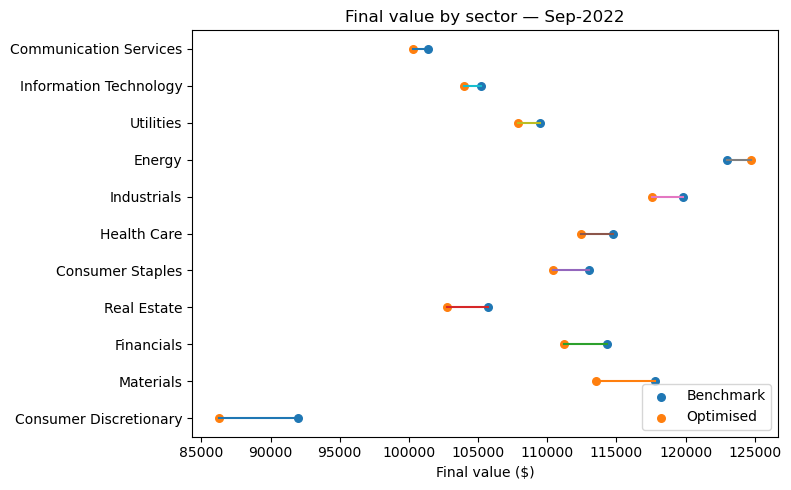

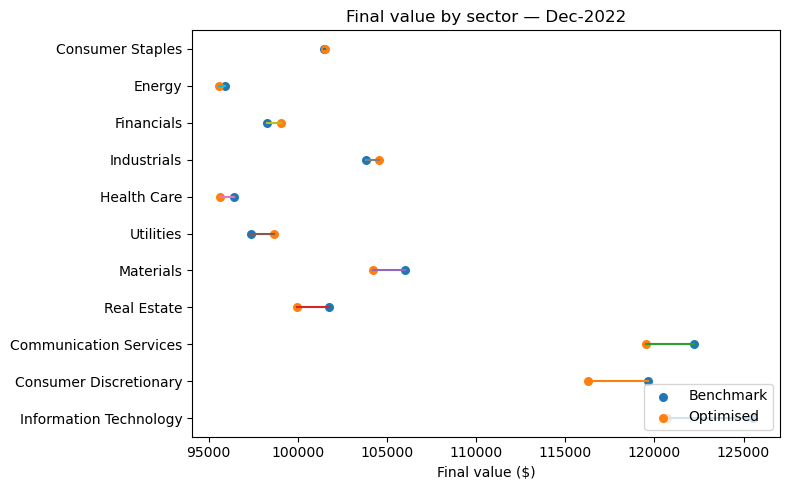

In [37]:
def plot_dumbbell(df_period, period_label=None):
    dfp = df_period.reindex(df_period['Difference ($)'].abs().sort_values(ascending=False).index)

    y = np.arange(len(dfp))

    fig, ax = plt.subplots(figsize=(8, 5))
    # lines between benchmark and optimised
    dfp.reset_index(inplace = True)
    for i, row in dfp.iterrows():

        ax.plot([row['Benchmark_Final'], row['Optimised_Final']], [y[i], y[i]])

    # markers
    ax.scatter(dfp['Benchmark_Final'], y, label='Benchmark', s=30)
    ax.scatter(dfp['Optimised_Final'], y, label='Optimised', s=30)

    ax.set_yticks(y)
    ax.set_yticklabels(dfp['Sector'])
    ax.set_xlabel('Final value ($)')
    ax.set_title(f'Final value by sector — {period_label}')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

# Example: draw for one period
for p in periods:

    plot_dumbbell(final_df[final_df['Period']==p], nice_label.get(p, p))


TE per sector:

In [28]:
import pandas as pd

# --- keep your existing part ---
files = {
    "te_1221.xlsx": "TE Dec 21",
    "te_0322.xlsx": "TE Mar 22",
    "te_0622.xlsx": "TE Jun 22",
    "te_0922.xlsx": "TE Sep 22",
    "te_1222.xlsx": "TE Dec 22"
}

def traffic_light(te):
    if te <= 0.025:
        return f"{te:.1%} 🟢"
    elif te <= 0.03:
        return f"{te:.1%} 🟡"
    else:
        return f"{te:.1%} 🔴"

# Store both formatted and raw TE
dfs = []
for f, label in files.items():
    df = pd.read_excel("Data/te-testing-results/" + f)
    df = df.rename(columns={"Unnamed: 0": "Sector"})
    df[label + "_raw"] = df["Annualised_TE"]  # keep raw value
    df[label] = df["Annualised_TE"].apply(traffic_light)
    dfs.append(df[["Sector", label, label + "_raw"]])

# Merge all
final_df = dfs[0]
for df in dfs[1:]:
    final_df = final_df.merge(df, on="Sector")

# --- Count greens, yellows, reds per sector ---
def classify(te):
    if te <= 0.025:
        return "green"
    elif te <= 0.03:
        return "yellow"
    else:
        return "red"

color_counts = []
for _, row in final_df.iterrows():
    raw_cols = [c for c in final_df.columns if c.endswith("_raw")]
    colors = [classify(row[c]) for c in raw_cols]
    counts = {c: colors.count(c) for c in ["green", "yellow", "red"]}
    color_counts.append(counts)

color_df = pd.DataFrame(color_counts, index=final_df["Sector"])
final_df = final_df.set_index("Sector")

# Merge counts into table
final_df = final_df.join(color_df)

# --- Sort by #greens (desc), then #yellows (desc), then #reds (asc) ---
final_df = final_df.sort_values(by=["green", "yellow", "red"], ascending=[False, False, True])

# Keep only pretty columns for display
pretty_cols = [c for c in final_df.columns if not c.endswith("_raw")]
print(final_df[pretty_cols])



                       TE Dec 21 TE Mar 22 TE Jun 22 TE Sep 22 TE Dec 22  \
Sector                                                                     
Energy                    1.4% 🟢    2.8% 🟡    1.9% 🟢    1.4% 🟢    1.8% 🟢   
Consumer Staples          2.2% 🟢    2.9% 🟡    2.1% 🟢    2.2% 🟢    1.9% 🟢   
Real Estate               1.4% 🟢    5.3% 🔴    2.3% 🟢    4.1% 🔴    2.4% 🟢   
Health Care               2.8% 🟡    2.9% 🟡    2.5% 🟡    2.2% 🟢    2.2% 🟢   
Materials                 3.0% 🟡    2.7% 🟡    2.4% 🟢    3.0% 🔴    2.4% 🟢   
Consumer Discretionary    2.0% 🟢    3.7% 🔴    2.3% 🟢    5.1% 🔴    2.7% 🟡   
Financials                1.9% 🟢    2.1% 🟢    2.9% 🟡    3.1% 🔴    5.5% 🔴   
Communication Services    4.0% 🔴    4.7% 🔴    1.6% 🟢    2.9% 🟡    2.4% 🟢   
Information Technology    3.1% 🔴    2.3% 🟢    2.3% 🟢    3.1% 🔴    3.0% 🔴   
Utilities                 2.6% 🟡    2.6% 🟡    2.7% 🟡    2.5% 🟡    2.4% 🟢   
Industrials               2.9% 🟡    3.1% 🔴    2.4% 🟢    2.9% 🟡    2.6% 🟡   

           

Results of investing 100k into the decarbonised portfolio (by aggregating the 11 single portfolio and weighting them based on the sector weights in the original benchmark) vs the real S&P 500 benchmark:

In [27]:
import pandas as pd
import glob

# Map periods to nice labels
labels = {
    "1221": "Dec 21 – Mar 22",
    "0322": "Mar 22 – Jun 22",
    "0622": "Jun 22 – Sep 22",
    "0922": "Sep 22 – Dec 22",
    "1222": "Dec 22 – Mar 23"
}

# Collect results
results = []

for file in glob.glob("Data/te-testing-results/benchmark_vs_decarb_final_value_proportional_*.xlsx"):
    period = file.split("_")[-1].split(".")[0]  # e.g. "0922"
    df = pd.read_excel(file, index_col=0)

    benchmark_val = df.loc["Benchmark", "Final value ($)"]
    decarb_val = df.loc["Decarbonised", "Final value ($)"]
    diff_val = df.loc["Difference", "Final value ($)"]

    benchmark_ret = df.loc["Benchmark", "Return (%)"]
    decarb_ret = df.loc["Decarbonised", "Return (%)"]
    diff_ret = df.loc["Difference", "Return (%)"]

    results.append({
        "Period": labels.get(period, period),
        "Benchmark ($)": benchmark_val,
        "Decarb ($)": decarb_val,
        "Difference ($)": diff_val,
        "Benchmark (%)": benchmark_ret,
        "Decarb (%)": decarb_ret,
        "Difference (%)": diff_ret
    })

# Define correct chronological order
period_order = [
    "Dec 21 – Mar 22",
    "Mar 22 – Jun 22",
    "Jun 22 – Sep 22",
    "Sep 22 – Dec 22",
    "Dec 22 – Mar 23"
]

# Turn Period into categorical with that order
summary_df.index = pd.CategoricalIndex(summary_df.index, categories=period_order, ordered=True)

# Sort by this order
summary_df = summary_df.sort_index()



# Format for presentation (1 decimal for %, round $ to 0)
summary_df_display = summary_df.copy()
summary_df_display[["Benchmark ($)", "Decarb ($)", "Difference ($)"]] = summary_df_display[["Benchmark ($)", "Decarb ($)", "Difference ($)"]].round(0).astype(int)
summary_df_display[["Benchmark (%)", "Decarb (%)", "Difference (%)"]] = (summary_df_display[["Benchmark (%)", "Decarb (%)", "Difference (%)"]] * 100).round(1)

summary_df_display = summary_df.copy()

# Format $ columns as whole numbers
summary_df_display[["Benchmark ($)", "Decarb ($)", "Difference ($)"]] = \
    summary_df_display[["Benchmark ($)", "Decarb ($)", "Difference ($)"]].round(0).astype(int)

# Format % columns with 1 decimal place
summary_df_display[["Benchmark (%)", "Decarb (%)", "Difference (%)"]] = \
    summary_df_display[["Benchmark (%)", "Decarb (%)", "Difference (%)"]].round(1)

print(summary_df_display)



                 Benchmark ($)  Decarb ($)  Difference ($)  Benchmark (%)  \
Period                                                                      
Dec 21 – Mar 22         102152      100751           -1401            2.2   
Mar 22 – Jun 22          85491       84257           -1234          -14.5   
Jun 22 – Sep 22          96772       96267            -505           -3.2   
Sep 22 – Dec 22         107016      104994           -2022            7.0   
Dec 22 – Mar 23         110703      108826           -1876           10.7   

                 Decarb (%)  Difference (%)  
Period                                       
Dec 21 – Mar 22         0.8            -1.4  
Mar 22 – Jun 22       -15.7            -1.4  
Jun 22 – Sep 22        -3.7            -0.5  
Sep 22 – Dec 22         5.0            -1.9  
Dec 22 – Mar 23         8.8            -1.7  
